Axl Waltz Cruz<br>
CPE311-CPE22S3<br>
03/05/26<br>
Engr. Neal Matira



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [2]:
path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")
print("Dataset path:", path)

100%|██████████| 3.64M/3.64M [00:00<00:00, 141MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/supplejade/rt-iot2022real-time-internet-of-things/versions/3


In [3]:
df = pd.read_csv(path + "/RT_IOT2022.csv")
df.head()

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   no                        123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio             123117 non-null  f

(123117, 85)

In [6]:
df.isnull().sum()
df = df.dropna()

In [7]:
df = df.drop_duplicates()

In [24]:
df.head()
print(df.columns.tolist())

['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [11]:
df.head()

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,-1.215900,0.211202,0.165266,tcp,mqtt,0.216931,0.301353,0.0936,0.07786,0.067497,...,-0.015925,3.191211,3.029218,0.213188,3.115811,-0.041693,3.105383,2.406197,-0.039563,MQTT_Publish
1,-1.215868,0.865405,0.165266,tcp,mqtt,0.215946,0.301353,0.0936,0.07786,0.067497,...,-0.015925,3.205525,3.042846,0.214214,3.129811,-0.041693,3.105383,2.406197,-0.039563,MQTT_Publish
2,-1.215835,0.530753,0.165266,tcp,mqtt,0.217796,0.301353,0.0936,0.07786,0.067497,...,-0.015925,3.204035,3.041427,0.214107,3.128353,-0.041693,3.105383,2.406197,-0.039563,MQTT_Publish
3,-1.215802,1.376665,0.165266,tcp,mqtt,0.216542,0.301353,0.0936,0.07786,0.067497,...,-0.015925,3.212165,3.049169,0.214689,3.136306,-0.041693,3.105383,2.406197,-0.039563,MQTT_Publish
4,-1.215769,0.862468,0.165266,tcp,mqtt,0.216090,0.301353,0.0936,0.07786,0.067497,...,-0.015925,3.200919,3.038461,0.213884,3.125306,-0.041693,3.105383,2.406197,-0.039563,MQTT_Publish


In [12]:
df.describe()

,no,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
count,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,...,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05
mean,5.078727e-17,2.031491e-17,-7.387239e-18,-3.823473e-18,-3.113606e-17,4.184178e-18,5.713568e-18,2.236371e-18,7.139074e-17,-1.625193e-16,...,-1.015745e-17,-2.088482e-18,-1.587102e-17,6.660058e-17,2.441973e-17,3.832130e-17,-5.049870e-18,1.277761e-16,-1.044602e-16,-5.632770e-17
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,...,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-1.215900e+00,-1.816375e+00,-1.929675e-01,-2.930325e-02,-1.015749e-01,-5.783205e-02,-7.492792e-02,-2.539992e-02,-9.488712e-01,-9.486569e-01,...,-9.183840e-02,-1.592498e-02,-1.835156e-01,-1.839495e-01,-2.861030e-02,-1.848540e-01,-4.169290e-02,-3.269303e-01,-2.734633e-01,-1.191171e-01
25%,-1.016977e+00,-8.881372e-01,-1.889724e-01,-2.930324e-02,-5.680510e-02,-2.754570e-02,-2.399876e-02,-2.539992e-02,-9.486702e-01,-9.484603e-01,...,-9.183780e-02,-1.592498e-02,-1.835156e-01,-1.839495e-01,-2.861030e-02,-1.848540e-01,-4.169290e-02,-3.235108e-01,-2.734633e-01,-1.089747e-01
50%,-1.291931e-01,1.353785e-01,-1.889724e-01,-2.930322e-02,-5.680510e-02,-2.754570e-02,-2.399876e-02,-2.539992e-02,-2.834225e-01,-2.832745e-01,...,-9.183588e-02,-1.592498e-02,-1.835156e-01,-1.839495e-01,-2.861030e-02,-1.848540e-01,-4.169290e-02,-3.235108e-01,-2.734633e-01,-1.089747e-01
75%,8.813134e-01,8.563858e-01,-1.889724e-01,-2.930321e-02,-5.680510e-02,-2.754570e-02,-2.399876e-02,-2.539992e-02,4.652074e-01,4.652806e-01,...,-9.183529e-02,-1.592498e-02,-1.835156e-01,-1.839495e-01,-2.861030e-02,-1.848540e-01,-4.169290e-02,-3.235108e-01,-2.734633e-01,-1.089747e-01
max,1.891820e+00,1.620077e+00,1.224703e+01,1.671055e+02,1.944233e+02,3.061977e+02,2.212123e+02,3.128828e+02,1.879286e+00,1.879218e+00,...,2.711375e+02,3.230620e+02,3.387117e+01,3.224042e+01,1.705100e+02,3.312247e+01,1.106488e+02,3.174575e+00,6.267734e+00,1.026652e+01


In [26]:
print(df.columns.tolist())
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.select_dtypes(include='object').columns
['Attack_type']


df['Attack_type'].value_counts()

['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd

,count
Attack_type,
DOS_SYN_Hping,94659
Thing_Speak,8108
ARP_poisioning,7750
MQTT_Publish,4146
NMAP_UDP_SCAN,2590
NMAP_XMAS_TREE_SCAN,2010
NMAP_OS_DETECTION,2000
NMAP_TCP_scan,1002
DDOS_Slowloris,534


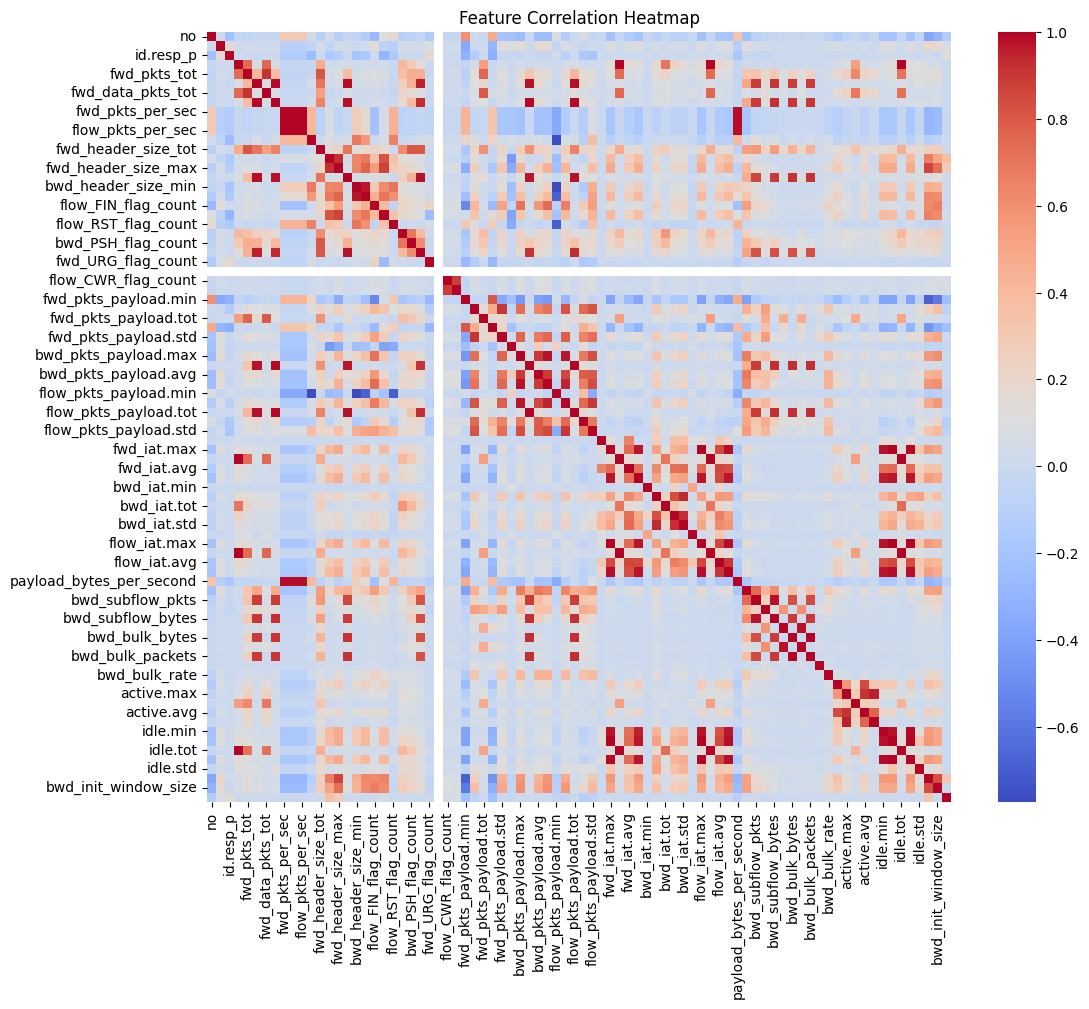

In [28]:
plt.figure(figsize=(12,10))

corr_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

In [15]:
df.to_csv("transformed_RT_IOT2022.csv", index=False)